## 1. Imports

In [12]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import joblib
import os

warnings.filterwarnings('ignore')

## 2. Load Data

In [13]:
# Notebook 2 (Training): Load
df_final = pd.read_parquet('../data/tehranhouses_preprocessed.parquet')
df_final.head()

,Area,Room,Parking,Warehouse,Elevator,Price(USD),Address_Abbasabad,Address_Absard,Address_Abuzar,Address_Afsarieh,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,-0.625034,-1.444908,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-0.667497,-1.444908,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.398569,-0.116257,1,1,1,18333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-0.172104,-0.116257,1,1,1,30083.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.224211,-0.116257,1,1,1,233333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
# Feature / Target Split
X = df_final.drop('Price(USD)', axis=1)
y = df_final['Price(USD)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2752, 196)  |  Test: (688, 196)


In [15]:
# mlp = MLPRegressor(
#     hidden_layer_sizes=(128, 64),
#     activation="relu",
#     solver="adam",
#     alpha=1e-2,               # L2 regularization
#     learning_rate_init=1e-3,
#     max_iter=3000,
#     early_stopping=True,
#     n_iter_no_change=25,
#     validation_fraction=0.1,
#     random_state=RANDOM_STATE,
# )
# param_grid = {
#     "model__regressor__hidden_layer_sizes": [(64,), (128, 64), (128, 64, 32)],
#     "model__regressor__alpha": [1e-3, 1e-2, 1e-1],
# }

In [16]:
from sklearn.neural_network import MLPRegressor

# Define the parameter grid for tuning
param_grid = {
    'hidden_layer_sizes': [(64,),],
    'activation': ['relu'], # tanh 
    'solver': ['adam'], # sgd
    'alpha': [0.05]
}

# Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=MLPRegressor(random_state=42, max_iter=5000),
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1          # Use all available CPU cores
)

# Run the grid search
grid_search.fit(X_train, y_train)

/home/rezazng/miniconda3/envs/Practice/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rezazng/miniconda3/envs/Practice/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rezazng/miniconda3/envs/Practice/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rezazng/miniconda3/envs/Practice/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't 

GridSearchCV(cv=5, estimator=MLPRegressor(max_iter=5000, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu'], 'alpha': [0.05],
                         'hidden_layer_sizes': [(64,)], 'solver': ['adam']},
             scoring='r2')

In [17]:
# Print out the best parameters and cross-validation score
print("Best hyperparameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy: {:.2f}".format(grid_search.best_score_ ))

model = grid_search.best_estimator_

# Predict & Evaluate
print(f"\nModel Performance On Test set:")

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"        R^2 Score: {r2:.4f}")
print(f"        MSE: {mse:.4f}")
print("         RMSE: %f" % (rmse))

Best hyperparameters found:
{'activation': 'relu', 'alpha': 0.05, 'hidden_layer_sizes': (64,), 'solver': 'adam'}

Best cross-validation accuracy: 0.50

Model Performance On Test set:
        R^2 Score: 0.5635
        MSE: 29757943850.4113
         RMSE: 172504.909641


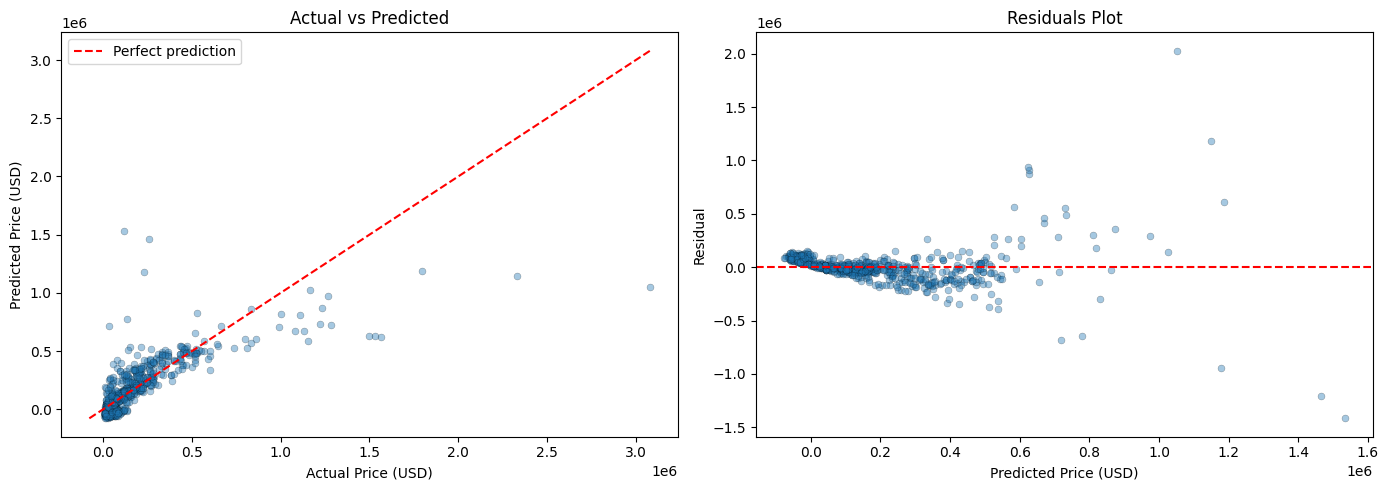

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_pred_best = model.predict(X_test)

# Scatter: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
lim = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)'); ax.set_ylabel('Predicted Price (USD)')
ax.set_title(f'Actual vs Predicted'); ax.legend()

# Residuals
ax = axes[1]
residuals = y_test.values - y_pred_best
ax.scatter(y_pred_best, residuals, alpha=0.4, edgecolors='k', linewidths=0.3, s=25)
ax.axhline(0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Price (USD)'); ax.set_ylabel('Residual')
ax.set_title('Residuals Plot')

plt.tight_layout(); plt.show()

### Feature Importances

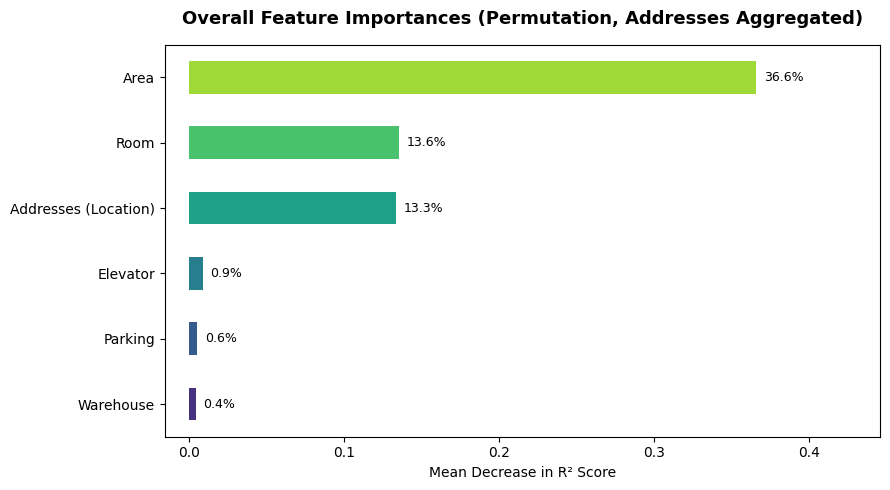

In [19]:
# Compute permutation importance on the test set
perm_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

imp = pd.Series(perm_result.importances_mean, index=X_train.columns)

# Extract and sum up all one-hot encoded 'Address_' column scores
address_mask = imp.index.str.startswith('Address_')
total_address_importance = imp[address_mask].sum()

# Build a new series grouping all other numerical features + the unified Address score
grouped_imp = imp[~address_mask].copy()
grouped_imp['Addresses (Location)'] = total_address_importance

# Sort for the plot
grouped_imp = grouped_imp.sort_values(ascending=True)

# Plot
plt.figure(figsize=(9, 5))
grouped_imp.plot.barh(color=sns.color_palette('viridis', len(grouped_imp)))

for i, val in enumerate(grouped_imp.values):
    offset = 0.005 if val >= 0 else -0.005
    plt.text(val + offset, i, f"{val*100:.1f}%", va='center',
              ha='left' if val >= 0 else 'right', fontsize=9, fontweight='medium')

plt.title('Overall Feature Importances (Permutation, Addresses Aggregated)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mean Decrease in R² Score')
plt.xlim(min(0, grouped_imp.min() - 0.02), max(grouped_imp.values) + 0.08)
plt.tight_layout()
plt.show()

## Save Trained Model

In [20]:
# # Save Trained Model
# os.makedirs('saved_models', exist_ok=True)

# model_filename = 'saved_models/tehran_housing_best_model.pkl'
# features_filename = 'saved_models/model_features.pkl'

# # Save the best model and the specific column layout
# joblib.dump(model, model_filename, compress=3)
# # joblib.dump(model, model_filename)
# joblib.dump(X_train.columns.tolist(), features_filename)